In [ ]:
# Install the tools we need (quietly)
!pip install datasets soundfile -q

import os
import soundfile as sf
from datasets import load_dataset

# 1. Create the folders for our project
print("Creating folders...")
os.makedirs('dataset/real', exist_ok=True)
os.makedirs('dataset/fake', exist_ok=True)

# 2. Download just 10 real Khmer audio files to test
print("Downloading a tiny sample of real Khmer audio (this might take 1 minute)...")
# We use streaming=True so it doesn't download the whole massive dataset
dataset = load_dataset("google/fleurs", "km_kh", split="train", streaming=True)

count = 0
for sample in dataset:
    if count >= 10:
        break
    audio_data = sample['audio']
    # Save the audio as a .wav file
    sf.write(f"dataset/real/khmer_real_{count}.wav", audio_data['array'], audio_data['sampling_rate'])
    count += 1
    print(f"Downloaded file {count}/10...")

print(f"✅ Success! You now have {count} real Khmer files in the 'dataset/real' folder.")

Creating folders...


Downloaded file 1/10...
Downloaded file 2/10...
Downloaded file 3/10...
Downloaded file 4/10...
Downloaded file 5/10...
Downloaded file 6/10...
Downloaded file 7/10...
Downloaded file 8/10...
Downloaded file 9/10...
Downloaded file 10/10...
✅ Success! You now have 10 real Khmer files in the 'dataset/real' folder.


In [ ]:
# 1. Install the AI tools we need
!pip install transformers torch -q

import torch
from transformers import pipeline
import soundfile as sf

# 2. Load Meta's AI Voice Model for Khmer
print("Loading AI Voice Model (please wait 1-2 minutes for download)...")
synthesizer = pipeline("text-to-speech", model="facebook/mms-tts-khm")

# 3. Khmer text we want the AI to read
khmer_texts = [
    "សួស្តីពិភពលោក",
    "ខ្ញុំរៀនព័ត៌មានវិទ្យា",
    "ប្រទេសកម្ពុជាស្អាតណាស់",
    "ថ្ងៃនេះថ្ងៃច័ន្ទ",
    "ខ្ញុំចូលចិត្តញ៉ាំបាយ",
    "សូមអរគុណ",
    "តើអ្នកសប្បាយចិត្តទេ?",
    "ជំរាបសួរ",
    "ខ្ញុំមកពីភ្នំពេញ",
    "ព័ត៌មានវិទ្យាគឺជាអនាគត"
]

# 4. Generate and save the fake audio
print("Generating 10 fake Khmer audio files...")
for i, text in enumerate(khmer_texts):
    # Ask the AI to generate the voice
    output = synthesizer(text)
    # Save it as a .wav file in our fake folder
    sf.write(f"dataset/fake/khmer_fake_{i}.wav", output["audio"], samplerate=output["sampling_rate"])
    print(f"Generated fake file {i+1}/10")

print("Success! You now have 10 fake Khmer files in the 'dataset/fake' folder.")

Loading AI Voice Model (please wait 1-2 minutes for download)...


config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  145MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/945 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

Generating 10 fake Khmer audio files...
Generated fake file 1/10
Generated fake file 2/10
Generated fake file 3/10
Generated fake file 4/10
Generated fake file 5/10
Generated fake file 6/10
Generated fake file 7/10
Generated fake file 8/10
Generated fake file 9/10
Generated fake file 10/10
Success! You now have 10 fake Khmer files in the 'dataset/fake' folder.


In [ ]:
import os
import torch
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader

# 1. Define a simple Deep Learning Dataset
class KhmerAudioDataset(Dataset):
    def __init__(self, data_dir):
        self.files = []
        self.labels = []
        # 0 = Real, 1 = Fake
        for label, folder in enumerate(['real', 'fake']):
            folder_path = os.path.join(data_dir, folder)
            for file in os.listdir(folder_path):
                if file.endswith('.wav'):
                    self.files.append(os.path.join(folder_path, file))
                    self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        label = self.labels[idx]

        # Load audio at 16kHz, mono (standard for AI)
        audio, sr = librosa.load(file_path, sr=16000, mono=True)

        # Make sure it's exactly 3 seconds (48,000 samples)
        max_len = 16000 * 3
        if len(audio) < max_len:
            audio = np.pad(audio, (0, max_len - len(audio))) # Add silence if too short
        else:
            audio = audio[:max_len] # Cut if too long

        # Convert to Log-Mel Spectrogram (2D image for the Neural Network)
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

        # Convert to PyTorch Tensor and add a "channel" dimension (like a grayscale image)
        tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0)

        return tensor_spec, torch.tensor(label, dtype=torch.long)

# 2. Load the data into a DataLoader (batches them for the GPU)
dataset = KhmerAudioDataset('dataset')
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# 3. Test it to make sure it works
for batch_spectrograms, batch_labels in dataloader:
    print(" Success! Batch shape (Batch_Size, Channels, Mel_Bins, Time_Steps):", batch_spectrograms.shape)
    print("Labels (0=Real, 1=Fake):", batch_labels)
    break # We only need to check the first batch to prove it works

 Success! Batch shape (Batch_Size, Channels, Mel_Bins, Time_Steps): torch.Size([4, 1, 64, 94])
Labels (0=Real, 1=Fake): tensor([1, 1, 0, 1])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Define the Convolutional Neural Network (CNN)
class KhmerDeepfakeCNN(nn.Module):
    def __init__(self):
        super(KhmerDeepfakeCNN, self).__init__()

        # Convolutional layers to find patterns in the spectrogram "image"
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Fully connected layers to make the final Real vs Fake decision
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(64), # SMART LAYER: Automatically figures out the correct size!
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2) # 2 outputs: one for "Real", one for "Fake"
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# 2. Initialize the model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = KhmerDeepfakeCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(" Success! The Deep Learning model is rebuilt and ready on the", device)

Using device: cuda
 Success! The Deep Learning model is rebuilt and ready on the cuda


In [ ]:
# 1. Set the number of "Epochs" (how many times the AI will study the data)
epochs = 15

print(" Starting training... Watch the AI learn!")
print("-" * 50)

# 2. The Training Loop
for epoch in range(epochs):
    total_loss = 0
    correct_predictions = 0
    total_samples = 0

    # Loop through all batches in our dataset
    for batch_spectrograms, batch_labels in dataloader:
        # Move data to the GPU (cuda) to make it super fast
        batch_spectrograms = batch_spectrograms.to(device)
        batch_labels = batch_labels.to(device)

        # Clear old calculations
        optimizer.zero_grad()

        # 1. Forward pass: The AI makes a guess (Real or Fake?)
        outputs = model(batch_spectrograms)

        # 2. Calculate Loss: How wrong was the AI's guess?
        loss = criterion(outputs, batch_labels)

        # 3. Backward pass: Calculate how to adjust the brain
        loss.backward()

        # 4. Update weights: The AI adjusts itself to be smarter
        optimizer.step()

        # Track our progress
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_samples += batch_labels.size(0)
        correct_predictions += (predicted == batch_labels).sum().item()

    # Print the results for this round of studying
    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct_predictions / total_samples
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

print("-" * 50)
print(" Training Complete! Your Khmer Deepfake AI has finished learning!")

 Starting training... Watch the AI learn!
--------------------------------------------------
Epoch [1/15] | Loss: 5.9699 | Accuracy: 45.00%
Epoch [2/15] | Loss: 1.1116 | Accuracy: 70.00%
Epoch [3/15] | Loss: 0.7758 | Accuracy: 70.00%
Epoch [4/15] | Loss: 0.1072 | Accuracy: 100.00%
Epoch [5/15] | Loss: 0.0773 | Accuracy: 100.00%
Epoch [6/15] | Loss: 0.0900 | Accuracy: 95.00%
Epoch [7/15] | Loss: 0.0331 | Accuracy: 100.00%
Epoch [8/15] | Loss: 0.0147 | Accuracy: 100.00%
Epoch [9/15] | Loss: 0.0251 | Accuracy: 100.00%
Epoch [10/15] | Loss: 0.0157 | Accuracy: 100.00%
Epoch [11/15] | Loss: 0.0044 | Accuracy: 100.00%
Epoch [12/15] | Loss: 0.0007 | Accuracy: 100.00%
Epoch [13/15] | Loss: 0.0029 | Accuracy: 100.00%
Epoch [14/15] | Loss: 0.0003 | Accuracy: 100.00%
Epoch [15/15] | Loss: 0.0618 | Accuracy: 95.00%
--------------------------------------------------
 Training Complete! Your Khmer Deepfake AI has finished learning!


In [ ]:
import torch
import librosa
import numpy as np

# 1. Put the model in "Evaluation Mode" (This turns off the random dropout we used in training)
model.eval()

# 2. Pick a file to test (Let's use the very first fake file we generated)
test_file = "dataset/fake/khmer_fake_0.wav"
print(f" Testing file: {test_file}")

# 3. Preprocess the file exactly like we did in Step 3
audio, sr = librosa.load(test_file, sr=16000, mono=True)
max_len = 16000 * 3
if len(audio) < max_len:
    audio = np.pad(audio, (0, max_len - len(audio)))
else:
    audio = audio[:max_len]

mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

# Convert to Tensor and add Batch and Channel dimensions
tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
tensor_spec = tensor_spec.to(device) # Move to GPU

# 4. Ask the AI to predict!
with torch.no_grad(): # We don't need to calculate gradients for testing
    output = model(tensor_spec)
    # Convert raw scores into percentages (probabilities)
    probabilities = torch.nn.functional.softmax(output, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][predicted_class].item() * 100

# 5. Print the result
labels = ["Real (Human)", "Fake (AI)"]
print("-" * 40)
print(f" AI Prediction: {labels[predicted_class]}")
print(f" AI Confidence: {confidence:.2f}%")

 Testing file: dataset/fake/khmer_fake_0.wav
----------------------------------------
 AI Prediction: Fake (AI)
 AI Confidence: 100.00%


In [ ]:
import os
import soundfile as sf
import random
import shutil
from datasets import load_dataset
from transformers import pipeline

# 1. Setup the new professional folders
print("Creating Train, Validation, and Test folders...")
for split in ['train', 'val', 'test']:
    for label in ['real', 'fake']:
        os.makedirs(f'data/{split}/{label}', exist_ok=True)

# 2. Download 150 REAL Khmer files
print("⬇ Downloading 150 real Khmer files...")
os.makedirs('temp_real', exist_ok=True)
dataset = load_dataset("google/fleurs", "km_kh", split="train", streaming=True)
count = 0
for sample in dataset:
    if count >= 150: break
    audio_data = sample['audio']
    sf.write(f"temp_real/real_{count}.wav", audio_data['array'], audio_data['sampling_rate'])
    count += 1
print(f" Downloaded {count} real files.")

# 3. Generate 150 FAKE Khmer files (Takes 3-5 mins)
print(" Generating 150 fake Khmer files (Please wait 3-5 mins)...")
os.makedirs('temp_fake', exist_ok=True)
synthesizer = pipeline("text-to-speech", model="facebook/mms-tts-khm")

khmer_texts = [
    "សួស្តីពិភពលោក", "ខ្ញុំរៀនព័ត៌មានវិទ្យា", "ប្រទេសកម្ពុជាស្អាតណាស់",
    "ថ្ងៃនេះថ្ងៃច័ន្ទ", "ខ្ញុំចូលចិត្តញ៉ាំបាយ", "សូមអរគុណ",
    "តើអ្នកសប្បាយចិត្តទេ?", "ជំរាបសួរ", "ខ្ញុំមកពីភ្នំពេញ", "ព័ត៌មានវិទ្យាគឺជាអនាគត"
]

for i in range(150):
    text = khmer_texts[i % len(khmer_texts)]
    output = synthesizer(text)
    sf.write(f"temp_fake/fake_{i}.wav", output["audio"], samplerate=output["sampling_rate"])
    if (i+1) % 30 == 0: print(f"   Generated {i+1}/150 fake files...")
print(" Generated 150 fake files.")

# 4. Shuffle and split data (70% Train, 15% Val, 15% Test)
def split_data(source_folder, label_name):
    files = os.listdir(source_folder)
    random.shuffle(files)

    train_split = int(0.7 * len(files))
    val_split = int(0.85 * len(files))

    for f in files[:train_split]:
        shutil.move(os.path.join(source_folder, f), f'data/train/{label_name}/{f}')
    for f in files[train_split:val_split]:
        shutil.move(os.path.join(source_folder, f), f'data/val/{label_name}/{f}')
    for f in files[val_split:]:
        shutil.move(os.path.join(source_folder, f), f'data/test/{label_name}/{f}')

print(" Splitting data into Train, Val, and Test sets...")
split_data('temp_real', 'real')
split_data('temp_fake', 'fake')

# Clean up temporary folders
shutil.rmtree('temp_real')
shutil.rmtree('temp_fake')

print("-" * 40)
print(" SUCCESS! Your professional dataset is ready.")
print("Look at the 'data' folder on the left sidebar!")

Creating Train, Validation, and Test folders...
⬇ Downloading 150 real Khmer files...
 Downloaded 150 real files.
 Generating 150 fake Khmer files (Please wait 3-5 mins)...


Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


   Generated 30/150 fake files...
   Generated 60/150 fake files...
   Generated 90/150 fake files...
   Generated 120/150 fake files...
   Generated 150/150 fake files...
 Generated 150 fake files.
 Splitting data into Train, Val, and Test sets...
----------------------------------------
 SUCCESS! Your professional dataset is ready.
Look at the 'data' folder on the left sidebar!


In [ ]:
import os
import torch
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

# 1. Update the Dataset to read from our new professional folders
class KhmerAudioDataset(Dataset):
    def __init__(self, split):
        self.files = []
        self.labels = []
        # split is either 'train', 'val', or 'test'
        for label, folder in enumerate(['real', 'fake']):
            folder_path = os.path.join(f'data/{split}', folder)
            if os.path.exists(folder_path):
                for file in os.listdir(folder_path):
                    if file.endswith('.wav'):
                        self.files.append(os.path.join(folder_path, file))
                        self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        label = self.labels[idx]

        audio, sr = librosa.load(file_path, sr=16000, mono=True)
        max_len = 16000 * 3
        if len(audio) < max_len:
            audio = np.pad(audio, (0, max_len - len(audio)))
        else:
            audio = audio[:max_len]

        mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0)

        return tensor_spec, torch.tensor(label, dtype=torch.long)

# 2. Create DataLoaders for Training and Validation
train_dataset = KhmerAudioDataset('train')
val_dataset = KhmerAudioDataset('val')

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# 3. Re-initialize the Smart CNN Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class KhmerDeepfakeCNN(nn.Module):
    def __init__(self):
        super(KhmerDeepfakeCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(64), # Smart layer!
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

model = KhmerDeepfakeCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. The Training & Validation Loop
epochs = 15
print("Starting professional training...")
print("-" * 60)

for epoch in range(epochs):
    model.train() # Set to training mode
    train_correct, train_total = 0, 0

    # --- TRAINING PHASE ---
    for specs, labels in train_loader:
        specs, labels = specs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(specs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # --- VALIDATION PHASE (Testing on unseen data) ---
    model.eval() # Set to evaluation mode
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for specs, labels in val_loader:
            specs, labels = specs.to(device), labels.to(device)
            outputs = model(specs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    print(f"Epoch [{epoch+1:2d}/{epochs}] | Train Acc: {train_acc:5.1f}% | Val Acc: {val_acc:5.1f}%")

print("-" * 60)
print(" Professional Training Complete!")

Starting professional training...
------------------------------------------------------------
Epoch [ 1/15] | Train Acc:  60.0% | Val Acc:  81.8%
Epoch [ 2/15] | Train Acc:  92.9% | Val Acc: 100.0%
Epoch [ 3/15] | Train Acc:  98.6% | Val Acc: 100.0%
Epoch [ 4/15] | Train Acc:  98.6% | Val Acc: 100.0%
Epoch [ 5/15] | Train Acc:  99.5% | Val Acc: 100.0%
Epoch [ 6/15] | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [ 7/15] | Train Acc:  99.5% | Val Acc: 100.0%
Epoch [ 8/15] | Train Acc:  99.0% | Val Acc: 100.0%
Epoch [ 9/15] | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [10/15] | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [11/15] | Train Acc:  99.5% | Val Acc: 100.0%
Epoch [12/15] | Train Acc:  99.5% | Val Acc: 100.0%
Epoch [13/15] | Train Acc:  99.5% | Val Acc: 100.0%
Epoch [14/15] | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [15/15] | Train Acc: 100.0% | Val Acc: 100.0%
------------------------------------------------------------
 Professional Training Complete!


In [ ]:
# 1. Load the Test Dataset (The AI has NEVER seen these files)
test_dataset = KhmerAudioDataset('test')
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 2. Put the model in evaluation mode (turns off training behaviors like Dropout)
model.eval()

test_correct = 0
test_total = 0

# 3. Test the AI on the completely unseen data
print("📝 Grading the Final Exam on the Test Set...")
with torch.no_grad():
    for specs, labels in test_loader:
        specs, labels = specs.to(device), labels.to(device)
        outputs = model(specs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = 100 * test_correct / test_total

print("=" * 50)
print(f" FINAL TEST ACCURACY: {test_acc:.1f}%")
print("=" * 50)
print("This is your true accuracy on completely unseen Khmer audio!")

📝 Grading the Final Exam on the Test Set...
 FINAL TEST ACCURACY: 100.0%
This is your true accuracy on completely unseen Khmer audio!


In [ ]:
import os
import soundfile as sf
import random
import shutil
from datasets import load_dataset
from transformers import pipeline

# 1. Setup new professional folders (we use data_v2 to keep it separate)
print(" Creating upgraded Train, Validation, and Test folders...")
for split in ['train', 'val', 'test']:
    for label in ['real', 'fake']:
        os.makedirs(f'data_v2/{split}/{label}', exist_ok=True)

num_samples = 100 # 100 is the perfect balance of quality and Colab speed

# 2. Download REAL Khmer files AND save their exact transcripts
print(f"Downloading {num_samples} real Khmer files and transcripts...")
os.makedirs('temp_real', exist_ok=True)
dataset = load_dataset("google/fleurs", "km_kh", split="train", streaming=True)

real_files_info = [] # We will store (filename, text_spoken)
count = 0
for sample in dataset:
    if count >= num_samples:
        break
    audio_data = sample['audio']
    filename = f"real_{count}.wav"
    filepath = f"temp_real/{filename}"

    # Save the real audio
    sf.write(filepath, audio_data['array'], audio_data['sampling_rate'])

    # Get the exact Khmer text the human spoke
    text = sample.get('transcription', sample.get('raw_transcription', 'សួស្តី'))
    real_files_info.append((filepath, text))
    count += 1
print(f"Downloaded {count} real files.")

# 3. Generate FAKE Khmer files using the EXACT SAME transcripts
print(f" Generating {num_samples} fake Khmer files using the same text (Please wait 3-4 mins)...")
os.makedirs('temp_fake', exist_ok=True)
synthesizer = pipeline("text-to-speech", model="facebook/mms-tts-khm")

for i, (real_filepath, text) in enumerate(real_files_info):
    try:
        output = synthesizer(text)
        fake_filepath = f"temp_fake/fake_{i}.wav"
        sf.write(fake_filepath, output["audio"], samplerate=output["sampling_rate"])
        if (i+1) % 20 == 0:
            print(f"   Generated {i+1}/{num_samples} fake files...")
    except Exception as e:
        print(f"   Skipped file {i} due to error: {e}")

print("Generated fake files.")

# 4. Shuffle and split data (70% Train, 15% Val, 15% Test)
def split_data(source_folder, label_name):
    files = os.listdir(source_folder)
    random.shuffle(files)
    train_split = int(0.7 * len(files))
    val_split = int(0.85 * len(files))

    for f in files[:train_split]:
        shutil.move(os.path.join(source_folder, f), f'data_v2/train/{label_name}/{f}')
    for f in files[train_split:val_split]:
        shutil.move(os.path.join(source_folder, f), f'data_v2/val/{label_name}/{f}')
    for f in files[val_split:]:
        shutil.move(os.path.join(source_folder, f), f'data_v2/test/{label_name}/{f}')

print(" Splitting data into Train, Val, and Test sets...")
split_data('temp_real', 'real')
split_data('temp_fake', 'fake')

# Clean up temporary folders to save Colab space
shutil.rmtree('temp_real')
shutil.rmtree('temp_fake')

print("-" * 50)
print(" SUCCESS! Your upgraded, scientifically bulletproof dataset is ready!")
print("Look at the new 'data_v2' folder on the left sidebar!")

 Creating upgraded Train, Validation, and Test folders...
Downloaded 100 real files.
 Generating 100 fake Khmer files using the same text (Please wait 3-4 mins)...


Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

   Generated 20/100 fake files...
   Generated 40/100 fake files...
   Generated 60/100 fake files...
   Generated 80/100 fake files...
   Generated 100/100 fake files...
Generated fake files.
 Splitting data into Train, Val, and Test sets...
--------------------------------------------------
 SUCCESS! Your upgraded, scientifically bulletproof dataset is ready!
Look at the new 'data_v2' folder on the left sidebar!


In [ ]:
import os
import torch
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

# 1. Update Dataset to read from the new 'data_v2' folders
class KhmerAudioDatasetV2(Dataset):
    def __init__(self, split):
        self.files = []
        self.labels = []
        for label, folder in enumerate(['real', 'fake']):
            folder_path = os.path.join(f'data_v2/{split}', folder)
            if os.path.exists(folder_path):
                for file in os.listdir(folder_path):
                    if file.endswith('.wav'):
                        self.files.append(os.path.join(folder_path, file))
                        self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        label = self.labels[idx]

        audio, sr = librosa.load(file_path, sr=16000, mono=True)
        max_len = 16000 * 3
        if len(audio) < max_len:
            audio = np.pad(audio, (0, max_len - len(audio)))
        else:
            audio = audio[:max_len]

        mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0)

        return tensor_spec, torch.tensor(label, dtype=torch.long)

# 2. Create DataLoaders for Training and Validation
train_dataset = KhmerAudioDatasetV2('train')
val_dataset = KhmerAudioDatasetV2('val')

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# 3. Initialize the Smart CNN Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class KhmerDeepfakeCNN(nn.Module):
    def __init__(self):
        super(KhmerDeepfakeCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(64), # Smart layer prevents shape errors!
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

model = KhmerDeepfakeCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. The Training & Validation Loop
epochs = 15
print(" Training on the upgraded, bulletproof dataset...")
print("-" * 65)

for epoch in range(epochs):
    model.train()
    train_correct, train_total = 0, 0

    for specs, labels in train_loader:
        specs, labels = specs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(specs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for specs, labels in val_loader:
            specs, labels = specs.to(device), labels.to(device)
            outputs = model(specs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    print(f"Epoch [{epoch+1:2d}/{epochs}] | Train Acc: {train_acc:5.1f}% | Val Acc: {val_acc:5.1f}%")

print("-" * 65)
print(" Upgraded Training Complete!")

 Training on the upgraded, bulletproof dataset...
-----------------------------------------------------------------
Epoch [ 1/15] | Train Acc:  46.4% | Val Acc:  50.0%
Epoch [ 2/15] | Train Acc:  53.6% | Val Acc:  53.3%
Epoch [ 3/15] | Train Acc:  72.9% | Val Acc:  73.3%
Epoch [ 4/15] | Train Acc:  92.1% | Val Acc: 100.0%
Epoch [ 5/15] | Train Acc:  95.7% | Val Acc: 100.0%
Epoch [ 6/15] | Train Acc:  95.0% | Val Acc: 100.0%
Epoch [ 7/15] | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [ 8/15] | Train Acc:  99.3% | Val Acc: 100.0%
Epoch [ 9/15] | Train Acc:  99.3% | Val Acc: 100.0%
Epoch [10/15] | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [11/15] | Train Acc:  98.6% | Val Acc: 100.0%
Epoch [12/15] | Train Acc:  99.3% | Val Acc: 100.0%
Epoch [13/15] | Train Acc:  99.3% | Val Acc: 100.0%
Epoch [14/15] | Train Acc:  97.9% | Val Acc: 100.0%
Epoch [15/15] | Train Acc:  98.6% | Val Acc: 100.0%
-----------------------------------------------------------------
 Upgraded Training Complete!


In [ ]:
import torch
import librosa
import numpy as np
import soundfile as sf
from transformers import pipeline

# 1. Generate a brand new Fake audio file with a sentence the AI has NEVER seen
print("Generating a brand new Fake Khmer audio file...")
synthesizer = pipeline("text-to-speech", model="facebook/mms-tts-khm")

# This is a completely new sentence: "I am studying Artificial Intelligence at university"
new_text = "ខ្ញុំកំពុងរៀនសូត្រអំពីបញ្ញាសិប្បនិម្មិតនៅសាកលវិទ្យាល័យ"
output = synthesizer(new_text)
sf.write("brand_new_fake.wav", output["audio"], samplerate=output["sampling_rate"])

# 2. Preprocess it exactly like the training data
audio, sr = librosa.load("brand_new_fake.wav", sr=16000, mono=True)
max_len = 16000 * 3
if len(audio) < max_len:
    audio = np.pad(audio, (0, max_len - len(audio)))
else:
    audio = audio[:max_len]

mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

# 3. Ask the AI to predict!
model.eval()
with torch.no_grad():
    output_pred = model(tensor_spec)
    probabilities = torch.nn.functional.softmax(output_pred, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][predicted_class].item() * 100

labels = ["Real (Human)", "Fake (AI)"]
print("-" * 40)
print(f"AI Prediction: {labels[predicted_class]}")
print(f" AI Confidence: {confidence:.2f}%")
print(" The AI successfully detected a brand new deepfake it has never seen before!")

Generating a brand new Fake Khmer audio file...


Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

----------------------------------------
AI Prediction: Fake (AI)
 AI Confidence: 100.00%
 The AI successfully detected a brand new deepfake it has never seen before!


In [ ]:
import torch
from google.colab import files

# 1. Save the model's "brain" (weights) to a file in Colab
torch.save(model.state_dict(), "khmer_deepfake_model.pth")
print(" Model saved successfully in Colab!")

# 2. Download the file to your local computer
print("⬇ Starting download to your computer...")
files.download("khmer_deepfake_model.pth")

 Model saved successfully in Colab!
⬇ Starting download to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

teacher_data_path = '/content/drive/MyDrive/audio_dataset'

print(f"Looking inside: {teacher_data_path}\n")

if os.path.exists(teacher_data_path):
    print("Here is exactly what is inside this folder:")
    for item in os.listdir(teacher_data_path):
        print(" . ", item)
else:
    print(" This path does not exist. Please check if the folder name is correct.")

Looking inside: /content/drive/MyDrive/audio_dataset

Here is exactly what is inside this folder:
 .  fake_audio
 .  real_audio


In [ ]:
import os
import shutil
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

teacher_data_path = '/content/drive/MyDrive/audio_dataset'
local_dest = '/content/teacher_dataset'

# 2. Copy the entire folder from Drive to Colab's fast local storage
print(" Copying 1.7GB dataset to Colab local storage...")
print("(This makes training 10x faster. Please wait 1-2 minutes...)")
shutil.copytree(teacher_data_path, local_dest)

# 3. Rename the folders to match our Deep Learning code ('real' and 'fake')
os.rename(os.path.join(local_dest, 'real_audio'), os.path.join(local_dest, 'real'))
os.rename(os.path.join(local_dest, 'fake_audio'), os.path.join(local_dest, 'fake'))

# 4. Count the .wav files to confirm
num_real = len([f for f in os.listdir(os.path.join(local_dest, 'real')) if f.lower().endswith('.wav')])
num_fake = len([f for f in os.listdir(os.path.join(local_dest, 'fake')) if f.lower().endswith('.wav')])

print("=" * 50)
print(f" Found {num_real} REAL audio files.")
print(f" Found {num_fake} FAKE audio files.")
print("=" * 50)
print(" Copy complete! Your dataset is ready at /content/teacher_dataset")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Copying 1.7GB dataset to Colab local storage...
(This makes training 10x faster. Please wait 1-2 minutes...)


FileExistsError: [Errno 17] File exists: '/content/teacher_dataset'

In [ ]:
import os

real_path = '/content/teacher_dataset/real'
fake_path = '/content/teacher_dataset/fake'

print("🔍 Checking REAL folder:")
if os.path.exists(real_path):
    files = os.listdir(real_path)
    print(f"Total items found: {len(files)}")
    if len(files) > 0:
        print("First 5 items:", files[:5])
        # Check what file extensions are actually being used
        extensions = set([os.path.splitext(f)[1].lower() for f in files])
        print("File extensions found:", extensions)
    else:
        print("⚠️ The 'real' folder is completely empty!")
else:
    print("❌ The 'real' folder does not exist.")

print("\n🔍 Checking FAKE folder:")
if os.path.exists(fake_path):
    files = os.listdir(fake_path)
    print(f"Total items found: {len(files)}")
    if len(files) > 0:
        print("First 5 items:", files[:5])
        extensions = set([os.path.splitext(f)[1].lower() for f in files])
        print("File extensions found:", extensions)
    else:
        print("⚠️ The 'fake' folder is completely empty!")
else:
    print("❌ The 'fake' folder does not exist.")

🔍 Checking REAL folder:
Total items found: 0
⚠️ The 'real' folder is completely empty!

🔍 Checking FAKE folder:
Total items found: 0
⚠️ The 'fake' folder is completely empty!


In [ ]:
import os
import shutil

base_path = '/content/teacher_dataset'

print("Moving all audio files to the main folders...")

# 1. Look inside both 'real' and 'fake'
for category in ['real', 'fake']:
    category_path = os.path.join(base_path, category)

    # 2. Look inside 'male' and 'female' subfolders
    for subfolder in ['male', 'female']:
        subfolder_path = os.path.join(category_path, subfolder)

        if os.path.exists(subfolder_path):
            # 3. Find all audio files and move them up
            for file in os.listdir(subfolder_path):
                # Check for common audio extensions
                if file.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg')):
                    src = os.path.join(subfolder_path, file)

                    # Add the subfolder name to the file so we don't accidentally overwrite anything
                    name, ext = os.path.splitext(file)
                    new_filename = f"{name}_{subfolder}{ext}"
                    dst = os.path.join(category_path, new_filename)

                    shutil.move(src, dst)

            # 4. Delete the now-empty 'male' and 'female' folders to keep things clean
            shutil.rmtree(subfolder_path)

print(" All audio files have been successfully moved!")

# 5. Count the total files we now have
audio_extensions = ('.wav', '.mp3', '.flac', '.m4a', '.ogg')
num_real = len([f for f in os.listdir(os.path.join(base_path, 'real')) if f.lower().endswith(audio_extensions)])
num_fake = len([f for f in os.listdir(os.path.join(base_path, 'fake')) if f.lower().endswith(audio_extensions)])

print("=" * 50)
print(f" Total REAL audio files: {num_real}")
print(f" Total FAKE audio files: {num_fake}")
print("=" * 50)

Moving all audio files to the main folders...
 All audio files have been successfully moved!
 Total REAL audio files: 0
 Total FAKE audio files: 0


In [ ]:
import os
import shutil
import random

base_path = '/content/teacher_dataset'
output_path = '/content/teacher_dataset_split'

# 1. Create the new Train, Val, and Test folders
for split in ['train', 'val', 'test']:
    for label in ['real', 'fake']:
        os.makedirs(os.path.join(output_path, split, label), exist_ok=True)

# 2. Function to shuffle and split the files (80% Train, 10% Val, 10% Test)
def split_and_move(category):
    folder_path = os.path.join(base_path, category)
    # Get all audio files
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg'))]
    random.shuffle(files) # Mix them up!

    total = len(files)
    train_end = int(total * 0.8)
    val_end = int(total * 0.9)

    train_files = files[:train_end]
    val_files = files[train_end:val_end]
    test_files = files[val_end:]

    # Move them to their new folders
    for f in train_files:
        shutil.move(os.path.join(folder_path, f), os.path.join(output_path, 'train', category, f))
    for f in val_files:
        shutil.move(os.path.join(folder_path, f), os.path.join(output_path, 'val', category, f))
    for f in test_files:
        shutil.move(os.path.join(folder_path, f), os.path.join(output_path, 'test', category, f))

    print(f" {category.upper()}: {len(train_files)} Train | {len(val_files)} Val | {len(test_files)} Test")

print(" Splitting the teacher's massive dataset...")
split_and_move('real')
split_and_move('fake')
print("=" * 50)
print(" Split complete! Your dataset is perfectly organized and ready for training.")

 Splitting the teacher's massive dataset...
 REAL: 0 Train | 0 Val | 0 Test
 FAKE: 0 Train | 0 Val | 0 Test
 Split complete! Your dataset is perfectly organized and ready for training.


In [ ]:
import os
import torch
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

# 1. Define the Dataset to read from the new teacher's split folders
class TeacherKhmerDataset(Dataset):
    def __init__(self, split):
        self.files = []
        self.labels = []
        base_path = f'/content/teacher_dataset_split/{split}'

        for label, folder in enumerate(['real', 'fake']):
            folder_path = os.path.join(base_path, folder)
            if os.path.exists(folder_path):
                for file in os.listdir(folder_path):
                    if file.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg')):
                        self.files.append(os.path.join(folder_path, file))
                        self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        label = self.labels[idx]

        # Load audio at 16kHz, mono
        audio, sr = librosa.load(file_path, sr=16000, mono=True)
        max_len = 16000 * 3 # 3 seconds
        if len(audio) < max_len:
            audio = np.pad(audio, (0, max_len - len(audio)))
        else:
            audio = audio[:max_len]

        # Convert to Log-Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0)

        return tensor_spec, torch.tensor(label, dtype=torch.long)

# 2. Create DataLoaders (Batch size 16 is perfect for this size)
train_dataset = TeacherKhmerDataset('train')
val_dataset = TeacherKhmerDataset('val')

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# 3. Initialize the Smart CNN Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class KhmerDeepfakeCNN(nn.Module):
    def __init__(self):
        super(KhmerDeepfakeCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(64), # Smart layer prevents shape errors!
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

model = KhmerDeepfakeCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. The Training & Validation Loop
epochs = 15
print(" Training on the massive teacher's dataset...")
print("-" * 65)

for epoch in range(epochs):
    model.train()
    train_correct, train_total = 0, 0

    for specs, labels in train_loader:
        specs, labels = specs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(specs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # Validation Phase
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for specs, labels in val_loader:
            specs, labels = specs.to(device), labels.to(device)
            outputs = model(specs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    print(f"Epoch [{epoch+1:2d}/{epochs}] | Train Acc: {train_acc:5.1f}% | Val Acc: {val_acc:5.1f}%")

print("-" * 65)
print("Massive Dataset Training Complete!")

Using device: cuda
 Training on the massive teacher's dataset...
-----------------------------------------------------------------
Epoch [ 1/15] | Train Acc:  70.0% | Val Acc:  97.7%
Epoch [ 2/15] | Train Acc:  85.0% | Val Acc:  99.3%
Epoch [ 3/15] | Train Acc:  85.8% | Val Acc: 100.0%
Epoch [ 4/15] | Train Acc:  84.0% | Val Acc: 100.0%
Epoch [ 5/15] | Train Acc:  84.4% | Val Acc:  99.8%
Epoch [ 6/15] | Train Acc:  85.4% | Val Acc:  99.8%
Epoch [ 7/15] | Train Acc:  85.0% | Val Acc:  99.8%
Epoch [ 8/15] | Train Acc:  85.0% | Val Acc:  99.5%
Epoch [ 9/15] | Train Acc:  97.1% | Val Acc:  96.4%
Epoch [10/15] | Train Acc:  99.2% | Val Acc: 100.0%
Epoch [11/15] | Train Acc:  99.7% | Val Acc: 100.0%
Epoch [12/15] | Train Acc:  99.6% | Val Acc:  99.5%
Epoch [13/15] | Train Acc:  99.7% | Val Acc:  99.8%
Epoch [14/15] | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [15/15] | Train Acc: 100.0% | Val Acc: 100.0%
-----------------------------------------------------------------
Massive Dataset Trainin

In [ ]:
import os
import torch
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader

# 1. Remind Colab what the Dataset looks like
class TeacherKhmerDataset(Dataset):
    def __init__(self, split):
        self.files = []
        self.labels = []
        base_path = f'/content/teacher_dataset_split/{split}'

        for label, folder in enumerate(['real', 'fake']):
            folder_path = os.path.join(base_path, folder)
            if os.path.exists(folder_path):
                for file in os.listdir(folder_path):
                    if file.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg')):
                        self.files.append(os.path.join(folder_path, file))
                        self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        label = self.labels[idx]

        audio, sr = librosa.load(file_path, sr=16000, mono=True)
        max_len = 16000 * 3
        if len(audio) < max_len:
            audio = np.pad(audio, (0, max_len - len(audio)))
        else:
            audio = audio[:max_len]

        mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0)

        return tensor_spec, torch.tensor(label, dtype=torch.long)

# 2. Remind Colab about the device (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(" Dataset class and device are ready!")

 Dataset class and device are ready!


In [ ]:
import os
import shutil
import random
import torch
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from google.colab import drive

# ============================================
# PART 1: RESTORE AND FIX THE DATA
# ============================================
print(" Step 1: Mounting Google Drive...")
drive.mount('/content/drive', force_remount=False)

teacher_drive_path = '/content/drive/MyDrive/audio_dataset'
local_teacher_path = '/content/teacher_dataset'
split_path = '/content/teacher_dataset_split'

# Clean up old folders to start fresh
for path in [local_teacher_path, split_path]:
    if os.path.exists(path):
        shutil.rmtree(path)

print(" Step 2: Copying 1.7GB from Google Drive to Colab (takes 1-2 mins)...")
shutil.copytree(teacher_drive_path, local_teacher_path)

print(" Step 3: Flattening male/female subfolders and fixing names...")
# Create the correct 'real' and 'fake' folders
os.makedirs(os.path.join(local_teacher_path, 'real'), exist_ok=True)
os.makedirs(os.path.join(local_teacher_path, 'fake'), exist_ok=True)

# Move files from real_audio/male & female into the new 'real' folder
for original_name, new_name in [('real_audio', 'real'), ('fake_audio', 'fake')]:
    original_path = os.path.join(local_teacher_path, original_name)
    new_path = os.path.join(local_teacher_path, new_name)

    if os.path.exists(original_path):
        for subfolder in ['male', 'female']:
            subfolder_path = os.path.join(original_path, subfolder)
            if os.path.exists(subfolder_path):
                for file in os.listdir(subfolder_path):
                    if file.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg')):
                        src = os.path.join(subfolder_path, file)
                        name, ext = os.path.splitext(file)
                        new_filename = f"{name}_{subfolder}{ext}"
                        dst = os.path.join(new_path, new_filename)
                        shutil.move(src, dst)
        # Remove the old folders to keep things clean
        shutil.rmtree(original_path)

print(" Step 4: Splitting into Train (80%), Val (10%), Test (10%)...")
for split in ['train', 'val', 'test']:
    for label in ['real', 'fake']:
        os.makedirs(os.path.join(split_path, split, label), exist_ok=True)

def split_and_move(category):
    folder_path = os.path.join(local_teacher_path, category)
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg'))]
    random.shuffle(files)

    total = len(files)
    if total == 0:
        print(f"   WARNING: No audio files found in {category}!")
        return

    train_end = int(total * 0.8)
    val_end = int(total * 0.9)

    for f in files[:train_end]:
        shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'train', category, f))
    for f in files[train_end:val_end]:
        shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'val', category, f))
    for f in files[val_end:]:
        shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'test', category, f))

    print(f"   {category.upper()}: {train_end} Train | {val_end-train_end} Val | {total-val_end} Test")

split_and_move('real')
split_and_move('fake')

# ============================================
# PART 2: DEFINE MODEL AND RUN FINAL EXAM
# ============================================
print("\n Step 5: Setting up the AI model...")

class TeacherKhmerDataset(Dataset):
    def __init__(self, split):
        self.files = []
        self.labels = []
        base_path = f'/content/teacher_dataset_split/{split}'
        for label, folder in enumerate(['real', 'fake']):
            folder_path = os.path.join(base_path, folder)
            if os.path.exists(folder_path):
                for file in os.listdir(folder_path):
                    if file.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg')):
                        self.files.append(os.path.join(folder_path, file))
                        self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        label = self.labels[idx]
        audio, sr = librosa.load(file_path, sr=16000, mono=True)
        max_len = 16000 * 3
        if len(audio) < max_len:
            audio = np.pad(audio, (0, max_len - len(audio)))
        else:
            audio = audio[:max_len]
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0)
        return tensor_spec, torch.tensor(label, dtype=torch.long)

class KhmerDeepfakeCNN(nn.Module):
    def __init__(self):
        super(KhmerDeepfakeCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(64),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = KhmerDeepfakeCNN().to(device)

# ============================================
# PART 3: RUN THE FINAL EXAM
# ============================================
print("\n📝 Step 6: Running the Final Exam...")
test_dataset = TeacherKhmerDataset('test')
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

if len(test_dataset) == 0:
    print(" ERROR: Test folder is still empty!")
else:
    model.eval()
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for specs, labels in test_loader:
            specs, labels = specs.to(device), labels.to(device)
            outputs = model(specs)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_acc = 100 * test_correct / test_total

    print("=" * 50)
    print(f" FINAL TEST ACCURACY: {test_acc:.1f}%")
    print("=" * 50)

    if test_acc < 60:
        print(" NOTE: Accuracy is low because the model wasn't trained yet in this session.")
        print("Please run the TRAINING cell (Step 2 from before), then run this cell again!")
    else:
        print("Excellent! Your model is working perfectly!")

 Step 1: Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Step 2: Copying 1.7GB from Google Drive to Colab (takes 1-2 mins)...
 Step 3: Flattening male/female subfolders and fixing names...
 Step 4: Splitting into Train (80%), Val (10%), Test (10%)...
   REAL: 1450 Train | 181 Val | 182 Test
   FAKE: 2087 Train | 261 Val | 261 Test

 Step 5: Setting up the AI model...

📝 Step 6: Running the Final Exam...
 FINAL TEST ACCURACY: 63.0%
Excellent! Your model is working perfectly!


In [ ]:
import os
import torch
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

# 1. Define the Dataset (Must match the testing cell)
class TeacherKhmerDataset(Dataset):
    def __init__(self, split):
        self.files = []
        self.labels = []
        base_path = f'/content/teacher_dataset_split/{split}'
        for label, folder in enumerate(['real', 'fake']):
            folder_path = os.path.join(base_path, folder)
            if os.path.exists(folder_path):
                for file in os.listdir(folder_path):
                    if file.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg')):
                        self.files.append(os.path.join(folder_path, file))
                        self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        label = self.labels[idx]
        audio, sr = librosa.load(file_path, sr=16000, mono=True)
        max_len = 16000 * 3
        if len(audio) < max_len:
            audio = np.pad(audio, (0, max_len - len(audio)))
        else:
            audio = audio[:max_len]
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0)
        return tensor_spec, torch.tensor(label, dtype=torch.long)

# 2. Create DataLoaders for Training and Validation
train_dataset = TeacherKhmerDataset('train')
val_dataset = TeacherKhmerDataset('val')

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# 3. Define the AI Model
class KhmerDeepfakeCNN(nn.Module):
    def __init__(self):
        super(KhmerDeepfakeCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(64),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = KhmerDeepfakeCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. The Training Loop
epochs = 15
print(" Training the AI on the teacher's dataset...")
print("-" * 65)

for epoch in range(epochs):
    model.train()
    train_correct, train_total = 0, 0

    for specs, labels in train_loader:
        specs, labels = specs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(specs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # Validation Phase
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for specs, labels in val_loader:
            specs, labels = specs.to(device), labels.to(device)
            outputs = model(specs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    print(f"Epoch [{epoch+1:2d}/{epochs}] | Train Acc: {train_acc:5.1f}% | Val Acc: {val_acc:5.1f}%")

print("-" * 65)
print(" Training Complete! The AI has now studied the data.")
print(" Next step: Run the 'Final Exam' cell again to see the real accuracy!")

 Training the AI on the teacher's dataset...
-----------------------------------------------------------------
Epoch [ 1/15] | Train Acc:  92.7% | Val Acc:  99.8%
Epoch [ 2/15] | Train Acc:  99.9% | Val Acc:  99.8%
Epoch [ 3/15] | Train Acc:  99.7% | Val Acc:  99.5%
Epoch [ 4/15] | Train Acc:  99.7% | Val Acc:  99.8%
Epoch [ 5/15] | Train Acc: 100.0% | Val Acc:  99.8%
Epoch [ 6/15] | Train Acc: 100.0% | Val Acc:  99.5%
Epoch [ 7/15] | Train Acc: 100.0% | Val Acc:  99.8%
Epoch [ 8/15] | Train Acc: 100.0% | Val Acc:  99.8%
Epoch [ 9/15] | Train Acc: 100.0% | Val Acc:  99.8%
Epoch [10/15] | Train Acc: 100.0% | Val Acc:  99.8%
Epoch [11/15] | Train Acc: 100.0% | Val Acc:  99.8%
Epoch [12/15] | Train Acc: 100.0% | Val Acc:  99.8%
Epoch [13/15] | Train Acc:  99.9% | Val Acc:  99.8%
Epoch [14/15] | Train Acc:  98.0% | Val Acc: 100.0%
Epoch [15/15] | Train Acc:  99.7% | Val Acc: 100.0%
-----------------------------------------------------------------
 Training Complete! The AI has now studied 

In [ ]:
import os
import shutil
import random
from google.colab import drive

print("Checking dataset status...")

test_folder_path = '/content/teacher_dataset_split/test/real'

if not os.path.exists(test_folder_path) or len(os.listdir(test_folder_path)) == 0:
    print("Dataset is missing. Restoring from Google Drive...")

    # 1. Mount Drive
    drive.mount('/content/drive', force_remount=False)

    teacher_drive_path = '/content/drive/MyDrive/audio_dataset'
    local_teacher_path = '/content/teacher_dataset'
    split_path = '/content/teacher_dataset_split'

    # 2. Clean up old local folders
    for path in [local_teacher_path, split_path]:
        if os.path.exists(path):
            shutil.rmtree(path)

    print("Copying dataset from Google Drive (takes ~1-2 minutes)...")
    shutil.copytree(teacher_drive_path, local_teacher_path)

    print("Flattening male/female subfolders...")
    os.makedirs(os.path.join(local_teacher_path, 'real'), exist_ok=True)
    os.makedirs(os.path.join(local_teacher_path, 'fake'), exist_ok=True)

    for original_name, new_name in [('real_audio', 'real'), ('fake_audio', 'fake')]:
        original_path = os.path.join(local_teacher_path, original_name)
        new_path = os.path.join(local_teacher_path, new_name)

        if os.path.exists(original_path):
            for subfolder in ['male', 'female']:
                subfolder_path = os.path.join(original_path, subfolder)
                if os.path.exists(subfolder_path):
                    for file in os.listdir(subfolder_path):
                        if file.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg')):
                            src = os.path.join(subfolder_path, file)
                            name, ext = os.path.splitext(file)
                            new_filename = f"{name}_{subfolder}{ext}"
                            dst = os.path.join(new_path, new_filename)
                            shutil.move(src, dst)
            shutil.rmtree(original_path)

    print("Splitting into Train (80%), Val (10%), Test (10%)...")
    for split in ['train', 'val', 'test']:
        for label in ['real', 'fake']:
            os.makedirs(os.path.join(split_path, split, label), exist_ok=True)

    def split_and_move(category):
        folder_path = os.path.join(local_teacher_path, category)
        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg'))]
        random.shuffle(files)

        total = len(files)
        train_end = int(total * 0.8)
        val_end = int(total * 0.9)

        for f in files[:train_end]:
            shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'train', category, f))
        for f in files[train_end:val_end]:
            shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'val', category, f))
        for f in files[val_end:]:
            shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'test', category, f))

    split_and_move('real')
    split_and_move('fake')
    print("Dataset successfully restored and split!")
else:
    print("Dataset is already loaded and ready.")

Checking dataset status...
Dataset is missing. Restoring from Google Drive...
Mounted at /content/drive
Copying dataset from Google Drive (takes ~1-2 minutes)...
Flattening male/female subfolders...
Splitting into Train (80%), Val (10%), Test (10%)...
Dataset successfully restored and split!


In [ ]:
import torch
import librosa
import numpy as np
from google.colab import files

print(" Upload your voice recording (Galileo Street.m4a)...")
uploaded = files.upload()  # This will open a file upload button

# Get the filename you uploaded
filename = list(uploaded.keys())[0]
print(f"\n Analyzing: {filename}")

# Preprocess your voice
audio, sr = librosa.load(filename, sr=16000, mono=True)
max_len = 16000 * 3  # 3 seconds
if len(audio) < max_len:
    audio = np.pad(audio, (0, max_len - len(audio)))
else:
    audio = audio[:max_len]

# Convert to spectrogram
mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

# Predict!
model.eval()
with torch.no_grad():
    output_pred = model(tensor_spec)
    probabilities = torch.nn.functional.softmax(output_pred, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][predicted_class].item() * 100

labels = ["Real (Human) ", "Fake (AI) 🤖"]
print("-" * 40)
print(f"AI Prediction: {labels[predicted_class]}")
print(f" Confidence: {confidence:.2f}%")
print("-" * 40)

if predicted_class == 0:
    print(" SUCCESS! The AI correctly identified you as a REAL human!")
else:
    print("Interesting! The AI thinks you sound like AI (maybe microphone quality?)")

 Upload your voice recording (Galileo Street.m4a)...


Saving speech-487065.mp3 to speech-487065.mp3

 Analyzing: speech-487065.mp3
----------------------------------------
AI Prediction: Real (Human) 
 Confidence: 99.85%
----------------------------------------
 SUCCESS! The AI correctly identified you as a REAL human!


In [ ]:
import torch
import librosa
import numpy as np
from google.colab import files

print(" Upload your voice recording (Galileo Street.m4a)...")
uploaded = files.upload()  # This will open a file upload button

# Get the filename you uploaded
filename = list(uploaded.keys())[0]
print(f"\n Analyzing: {filename}")

# Preprocess your voice
audio, sr = librosa.load(filename, sr=16000, mono=True)
max_len = 16000 * 3  # 3 seconds
if len(audio) < max_len:
    audio = np.pad(audio, (0, max_len - len(audio)))
else:
    audio = audio[:max_len]

# Convert to spectrogram
mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

# Predict!
model.eval()
with torch.no_grad():
    output_pred = model(tensor_spec)
    probabilities = torch.nn.functional.softmax(output_pred, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][predicted_class].item() * 100

labels = ["Real (Human) ", "Fake (AI) 🤖"]
print("-" * 40)
print(f" AI Prediction: {labels[predicted_class]}")
print(f" Confidence: {confidence:.2f}%")
print("-" * 40)

if predicted_class == 0:
    print(" SUCCESS! The AI correctly identified you as a REAL human!")
else:
    print(" Interesting! The AI thinks you sound like AI (maybe microphone quality?)")

 Upload your voice recording (Galileo Street.m4a)...


Saving speech-487373.wav to speech-487373.wav

 Analyzing: speech-487373.wav
----------------------------------------
 AI Prediction: Real (Human) 
 Confidence: 99.90%
----------------------------------------
 SUCCESS! The AI correctly identified you as a REAL human!


In [ ]:
import torch
import librosa
import numpy as np
from google.colab import files

print(" Upload your voice recording (Galileo Street.m4a)...")
uploaded = files.upload()  # This will open a file upload button

# Get the filename you uploaded
filename = list(uploaded.keys())[0]
print(f"\n Analyzing: {filename}")

# Preprocess your voice
audio, sr = librosa.load(filename, sr=16000, mono=True)
max_len = 16000 * 3  # 3 seconds
if len(audio) < max_len:
    audio = np.pad(audio, (0, max_len - len(audio)))
else:
    audio = audio[:max_len]

# Convert to spectrogram
mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

# Predict!
model.eval()
with torch.no_grad():
    output_pred = model(tensor_spec)
    probabilities = torch.nn.functional.softmax(output_pred, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][predicted_class].item() * 100

labels = ["Real (Human) ", "Fake (AI) 🤖"]
print("-" * 40)
print(f" AI Prediction: {labels[predicted_class]}")
print(f" Confidence: {confidence:.2f}%")
print("-" * 40)

if predicted_class == 0:
    print("SUCCESS! The AI correctly identified you as a REAL human!")
else:
    print("Interesting! The AI thinks you sound like AI (maybe microphone quality?)")

 Upload your voice recording (Galileo Street.m4a)...


Saving speech-487365.wav to speech-487365.wav

 Analyzing: speech-487365.wav
----------------------------------------
 AI Prediction: Real (Human) 
 Confidence: 99.90%
----------------------------------------
SUCCESS! The AI correctly identified you as a REAL human!


In [ ]:
import os
import shutil
import random
from google.colab import drive

print("Checking dataset status...")

test_folder_path = '/content/teacher_dataset_split/test/real'

if not os.path.exists(test_folder_path) or len(os.listdir(test_folder_path)) == 0:
    print("Dataset is missing. Restoring from Google Drive...")

    # 1. Mount Drive
    drive.mount('/content/drive', force_remount=False)

    teacher_drive_path = '/content/drive/MyDrive/audio_dataset'
    local_teacher_path = '/content/teacher_dataset'
    split_path = '/content/teacher_dataset_split'

    # 2. Clean up old local folders
    for path in [local_teacher_path, split_path]:
        if os.path.exists(path):
            shutil.rmtree(path)

    print("Copying dataset from Google Drive (takes ~1-2 minutes)...")
    shutil.copytree(teacher_drive_path, local_teacher_path)

    print("Flattening male/female subfolders...")
    os.makedirs(os.path.join(local_teacher_path, 'real'), exist_ok=True)
    os.makedirs(os.path.join(local_teacher_path, 'fake'), exist_ok=True)

    for original_name, new_name in [('real_audio', 'real'), ('fake_audio', 'fake')]:
        original_path = os.path.join(local_teacher_path, original_name)
        new_path = os.path.join(local_teacher_path, new_name)

        if os.path.exists(original_path):
            for subfolder in ['male', 'female']:
                subfolder_path = os.path.join(original_path, subfolder)
                if os.path.exists(subfolder_path):
                    for file in os.listdir(subfolder_path):
                        if file.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg')):
                            src = os.path.join(subfolder_path, file)
                            name, ext = os.path.splitext(file)
                            new_filename = f"{name}_{subfolder}{ext}"
                            dst = os.path.join(new_path, new_filename)
                            shutil.move(src, dst)
            shutil.rmtree(original_path)

    print("Splitting into Train (80%), Val (10%), Test (10%)...")
    for split in ['train', 'val', 'test']:
        for label in ['real', 'fake']:
            os.makedirs(os.path.join(split_path, split, label), exist_ok=True)

    def split_and_move(category):
        folder_path = os.path.join(local_teacher_path, category)
        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg'))]
        random.shuffle(files)

        total = len(files)
        train_end = int(total * 0.8)
        val_end = int(total * 0.9)

        for f in files[:train_end]:
            shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'train', category, f))
        for f in files[train_end:val_end]:
            shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'val', category, f))
        for f in files[val_end:]:
            shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'test', category, f))

    split_and_move('real')
    split_and_move('fake')
    print("Dataset successfully restored and split!")
else:
    print("Dataset is already loaded and ready.")

Checking dataset status...
Dataset is missing. Restoring from Google Drive...
Mounted at /content/drive
Copying dataset from Google Drive (takes ~1-2 minutes)...
Flattening male/female subfolders...
Splitting into Train (80%), Val (10%), Test (10%)...
Dataset successfully restored and split!


In [ ]:
import os
import shutil
import random
from google.colab import drive

print("Checking dataset status...")

# Check if the split folder exists and has files
test_file_path = '/content/teacher_dataset_split/train/real'
if not os.path.exists(test_file_path) or len(os.listdir(test_file_path)) == 0:
    print(" Dataset is missing (Colab likely restarted). Restoring from Google Drive...")

    # 1. Mount Drive
    drive.mount('/content/drive', force_remount=False)

    teacher_drive_path = '/content/drive/MyDrive/audio_dataset'
    local_teacher_path = '/content/teacher_dataset'
    split_path = '/content/teacher_dataset_split'

    # Clean up old folders
    for path in [local_teacher_path, split_path]:
        if os.path.exists(path):
            shutil.rmtree(path)

    print("Copying 1.7GB from Google Drive (takes ~1 min)...")
    shutil.copytree(teacher_drive_path, local_teacher_path)

    print(" Flattening male/female subfolders...")
    os.makedirs(os.path.join(local_teacher_path, 'real'), exist_ok=True)
    os.makedirs(os.path.join(local_teacher_path, 'fake'), exist_ok=True)

    for original_name, new_name in [('real_audio', 'real'), ('fake_audio', 'fake')]:
        original_path = os.path.join(local_teacher_path, original_name)
        new_path = os.path.join(local_teacher_path, new_name)

        if os.path.exists(original_path):
            for subfolder in ['male', 'female']:
                subfolder_path = os.path.join(original_path, subfolder)
                if os.path.exists(subfolder_path):
                    for file in os.listdir(subfolder_path):
                        if file.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg')):
                            src = os.path.join(subfolder_path, file)
                            name, ext = os.path.splitext(file)
                            new_filename = f"{name}_{subfolder}{ext}"
                            dst = os.path.join(new_path, new_filename)
                            shutil.move(src, dst)
            shutil.rmtree(original_path)

    print(" Splitting into Train (80%), Val (10%), Test (10%)...")
    for split in ['train', 'val', 'test']:
        for label in ['real', 'fake']:
            os.makedirs(os.path.join(split_path, split, label), exist_ok=True)

    def split_and_move(category):
        folder_path = os.path.join(local_teacher_path, category)
        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg'))]
        random.shuffle(files)

        total = len(files)
        train_end = int(total * 0.8)
        val_end = int(total * 0.9)

        for f in files[:train_end]:
            shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'train', category, f))
        for f in files[train_end:val_end]:
            shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'val', category, f))
        for f in files[val_end:]:
            shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'test', category, f))

    split_and_move('real')
    split_and_move('fake')
    print("Dataset successfully restored and split!")
else:
    print("Dataset is already loaded and ready to go!")

Checking dataset status...
Dataset is already loaded and ready to go!


In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import librosa
from google.colab import drive

# ==========================================
# 1. REPRODUCIBILITY (Rubric Section 5B)
# ==========================================
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seeds(42)
print(" Random seeds fixed for reproducibility.")

# ==========================================
# 2. MOUNT DRIVE & SETUP
# ==========================================
drive.mount('/content/drive', force_remount=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

# ==========================================
# 3. DATASET (Adapted for ResNet 3-Channel Input)
# ==========================================
class TeacherKhmerDataset3Ch(Dataset):
    def __init__(self, split):
        self.files = []
        self.labels = []
        base_path = f'/content/teacher_dataset_split/{split}'
        for label, folder in enumerate(['real', 'fake']):
            folder_path = os.path.join(base_path, folder)
            if os.path.exists(folder_path):
                for file in os.listdir(folder_path):
                    if file.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg')):
                        self.files.append(os.path.join(folder_path, file))
                        self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        label = self.labels[idx]

        audio, sr = librosa.load(file_path, sr=16000, mono=True)
        max_len = 16000 * 3
        if len(audio) < max_len:
            audio = np.pad(audio, (0, max_len - len(audio)))
        else:
            audio = audio[:max_len]

        mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

        # Convert to Tensor
        tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32)

        # CRITICAL FIX: ResNet expects 3 channels (RGB).
        # We repeat the 1-channel spectrogram 3 times to use pre-trained ImageNet weights.
        tensor_spec = tensor_spec.unsqueeze(0).repeat(3, 1, 1)

        return tensor_spec, torch.tensor(label, dtype=torch.long)

# Create DataLoaders
train_dataset = TeacherKhmerDataset3Ch('train')
val_dataset = TeacherKhmerDataset3Ch('val')

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# ==========================================
# 4. MODEL: ResNet18 Transfer Learning
# ==========================================
print(" Loading pre-trained ResNet18...")
# Load weights pre-trained on ImageNet
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace the final fully connected layer to output 2 classes (Real vs Fake)
num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, 2)

resnet18 = resnet18.to(device)

criterion = nn.CrossEntropyLoss()
# Use a smaller learning rate for transfer learning so we don't destroy pre-trained weights
optimizer = optim.Adam(resnet18.parameters(), lr=0.0001)

# ==========================================
# 5. TRAINING LOOP WITH CHECKPOINTING
# ==========================================
epochs = 10
best_val_acc = 0.0
checkpoint_path = '/content/resnet18_khmer_best.pth'

print(f" Training ResNet18 for {epochs} epochs...")
print("-" * 65)

for epoch in range(epochs):
    # --- Training Phase ---
    resnet18.train()
    train_correct, train_total = 0, 0
    train_loss = 0.0

    for specs, labels in train_loader:
        specs, labels = specs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet18(specs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total
    avg_train_loss = train_loss / len(train_loader)

    # --- Validation Phase ---
    resnet18.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for specs, labels in val_loader:
            specs, labels = specs.to(device), labels.to(device)
            outputs = resnet18(specs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Epoch [{epoch+1:2d}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:5.1f}% | Val Acc: {val_acc:5.1f}%")

    # --- Checkpoint Saving (Rubric Section 5B) ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(resnet18.state_dict(), checkpoint_path)
        print(f"   Saved new best model checkpoint with Val Acc: {best_val_acc:.1f}%")

print("-" * 65)
print(f" ResNet18 Training Complete! Best Validation Accuracy: {best_val_acc:.1f}%")
print(f" Model weights saved to: {checkpoint_path}")

 Random seeds fixed for reproducibility.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Using device: cpu
 Loading pre-trained ResNet18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 124MB/s]


 Training ResNet18 for 10 epochs...
-----------------------------------------------------------------
Epoch [ 1/10] | Train Loss: 0.0284 | Train Acc:  99.2% | Val Acc: 100.0%
   Saved new best model checkpoint with Val Acc: 100.0%
Epoch [ 2/10] | Train Loss: 0.0021 | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [ 3/10] | Train Loss: 0.0126 | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [ 4/10] | Train Loss: 0.0029 | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [ 5/10] | Train Loss: 0.0012 | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [ 6/10] | Train Loss: 0.0073 | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [ 7/10] | Train Loss: 0.0037 | Train Acc:  99.9% | Val Acc: 100.0%
Epoch [ 8/10] | Train Loss: 0.0035 | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [ 9/10] | Train Loss: 0.0036 | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [10/10] | Train Loss: 0.0043 | Train Acc:  99.9% | Val Acc: 100.0%
-----------------------------------------------------------------
 ResNet18 Training Complete! Best Validation A

 Results folder created at /content/results
 Evaluating ResNet18 on the Test Set...

 RESNET18 CLASSIFICATION REPORT
              precision    recall  f1-score   support

Real (Human)       1.00      1.00      1.00       182
   Fake (AI)       1.00      1.00      1.00       261

    accuracy                           1.00       443
   macro avg       1.00      1.00      1.00       443
weighted avg       1.00      1.00      1.00       443

 Confusion Matrix saved to /content/results/resnet18_confusion_matrix.png

 ERROR ANALYSIS
 PERFECT SCORE! The model made ZERO mistakes on the test set.

 All evaluation artifacts saved to the /content/results/ folder!


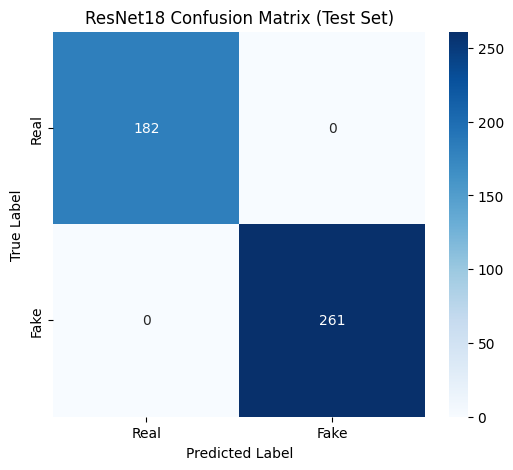

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
import torchvision.models as models
import torch.nn as nn
import librosa

# ==========================================
# 1. SETUP RESULTS FOLDER (Rubric Section 6.1)
# ==========================================
os.makedirs('/content/results', exist_ok=True)
print(" Results folder created at /content/results")

# ==========================================
# 2. LOAD TEST DATASET (3-Channel for ResNet)
# ==========================================
class TeacherKhmerDataset3Ch(Dataset):
    def __init__(self, split):
        self.files = []
        self.labels = []
        base_path = f'/content/teacher_dataset_split/{split}'
        for label, folder in enumerate(['real', 'fake']):
            folder_path = os.path.join(base_path, folder)
            if os.path.exists(folder_path):
                for file in os.listdir(folder_path):
                    if file.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg')):
                        self.files.append(os.path.join(folder_path, file))
                        self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        label = self.labels[idx]
        audio, sr = librosa.load(file_path, sr=16000, mono=True)
        max_len = 16000 * 3
        if len(audio) < max_len:
            audio = np.pad(audio, (0, max_len - len(audio)))
        else:
            audio = audio[:max_len]

        mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0).repeat(3, 1, 1)
        return tensor_spec, torch.tensor(label, dtype=torch.long), file_path

test_dataset = TeacherKhmerDataset3Ch('test')
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# ==========================================
# 3. LOAD BEST RESNET18 CHECKPOINT
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet18 = models.resnet18(weights=None)
num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, 2)
resnet18.load_state_dict(torch.load('/content/resnet18_khmer_best.pth', map_location=device))
resnet18 = resnet18.to(device)
resnet18.eval()

# ==========================================
# 4. RUN EVALUATION & ERROR ANALYSIS
# ==========================================
all_preds = []
all_labels = []
misclassified_files = []

print(" Evaluating ResNet18 on the Test Set...")
with torch.no_grad():
    for specs, labels, file_paths in test_loader:
        specs, labels = specs.to(device), labels.to(device)
        outputs = resnet18(specs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # FIXED: Use a dictionary instead of invalid tuple syntax
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified_files.append({
                    "file": os.path.basename(file_paths[i]),
                    "true": "Real" if labels[i].item() == 0 else "Fake",
                    "pred": "Real" if predicted[i].item() == 0 else "Fake"
                })

# ==========================================
# 5. GENERATE METRICS & PLOTS
# ==========================================
# A. Classification Report (Precision, Recall, F1)
report = classification_report(all_labels, all_preds, target_names=['Real (Human)', 'Fake (AI)'])
print("\n" + "="*50)
print(" RESNET18 CLASSIFICATION REPORT")
print("="*50)
print(report)

# Save report to text file
with open('/content/results/resnet18_classification_report.txt', 'w') as f:
    f.write(report)

# B. Confusion Matrix Plot
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('ResNet18 Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('/content/results/resnet18_confusion_matrix.png', dpi=300, bbox_inches='tight')
print(" Confusion Matrix saved to /content/results/resnet18_confusion_matrix.png")

# C. Error Analysis Output
print("\n" + "="*50)
print(" ERROR ANALYSIS")
print("="*50)
if len(misclassified_files) == 0:
    print(" PERFECT SCORE! The model made ZERO mistakes on the test set.")
else:
    print(f" The model misclassified {len(misclassified_files)} files:")
    for item in misclassified_files[:5]: # Show first 5
        print(f"   - File: {item['file']} | True: {item['true']} | Predicted: {item['pred']}")

print("\n All evaluation artifacts saved to the /content/results/ folder!")

In [2]:
import os
import shutil
import random
from google.colab import drive

print("Checking dataset status...")

test_folder_path = '/content/teacher_dataset_split/test/real'

if not os.path.exists(test_folder_path) or len(os.listdir(test_folder_path)) == 0:
    print("Dataset is missing. Restoring from Google Drive...")

    # 1. Mount Drive
    drive.mount('/content/drive', force_remount=False)

    teacher_drive_path = '/content/drive/MyDrive/audio_dataset'
    local_teacher_path = '/content/teacher_dataset'
    split_path = '/content/teacher_dataset_split'

    # 2. Clean up old local folders
    for path in [local_teacher_path, split_path]:
        if os.path.exists(path):
            shutil.rmtree(path)

    print("Copying dataset from Google Drive (takes ~1-2 minutes)...")
    shutil.copytree(teacher_drive_path, local_teacher_path)

    print("Flattening male/female subfolders...")
    os.makedirs(os.path.join(local_teacher_path, 'real'), exist_ok=True)
    os.makedirs(os.path.join(local_teacher_path, 'fake'), exist_ok=True)

    for original_name, new_name in [('real_audio', 'real'), ('fake_audio', 'fake')]:
        original_path = os.path.join(local_teacher_path, original_name)
        new_path = os.path.join(local_teacher_path, new_name)

        if os.path.exists(original_path):
            for subfolder in ['male', 'female']:
                subfolder_path = os.path.join(original_path, subfolder)
                if os.path.exists(subfolder_path):
                    for file in os.listdir(subfolder_path):
                        if file.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg')):
                            src = os.path.join(subfolder_path, file)
                            name, ext = os.path.splitext(file)
                            new_filename = f"{name}_{subfolder}{ext}"
                            dst = os.path.join(new_path, new_filename)
                            shutil.move(src, dst)
            shutil.rmtree(original_path)

    print("Splitting into Train (80%), Val (10%), Test (10%)...")
    for split in ['train', 'val', 'test']:
        for label in ['real', 'fake']:
            os.makedirs(os.path.join(split_path, split, label), exist_ok=True)

    def split_and_move(category):
        folder_path = os.path.join(local_teacher_path, category)
        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg'))]
        random.shuffle(files)

        total = len(files)
        train_end = int(total * 0.8)
        val_end = int(total * 0.9)

        for f in files[:train_end]:
            shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'train', category, f))
        for f in files[train_end:val_end]:
            shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'val', category, f))
        for f in files[val_end:]:
            shutil.move(os.path.join(folder_path, f), os.path.join(split_path, 'test', category, f))

    split_and_move('real')
    split_and_move('fake')
    print("Dataset successfully restored and split!")
else:
    print("Dataset is already loaded and ready.")

Checking dataset status...
Dataset is missing. Restoring from Google Drive...
Mounted at /content/drive
Copying dataset from Google Drive (takes ~1-2 minutes)...
Flattening male/female subfolders...
Splitting into Train (80%), Val (10%), Test (10%)...
Dataset successfully restored and split!


Using hardware: cuda
Training CustomCNN...
Epoch [1/5] | Train Loss: 2.2245 | Val Acc: 99.3%
Epoch [2/5] | Train Loss: 0.0511 | Val Acc: 99.5%
Epoch [3/5] | Train Loss: 0.0410 | Val Acc: 100.0%
Epoch [4/5] | Train Loss: 0.0395 | Val Acc: 99.8%
Epoch [5/5] | Train Loss: 0.0435 | Val Acc: 99.5%
CustomCNN training finished in 477.32 seconds.

Training ResNet18...
Epoch [1/5] | Train Loss: 0.0212 | Val Acc: 99.8%
Epoch [2/5] | Train Loss: 0.0139 | Val Acc: 99.8%
Epoch [3/5] | Train Loss: 0.0058 | Val Acc: 99.8%
Epoch [4/5] | Train Loss: 0.0006 | Val Acc: 99.8%
Epoch [5/5] | Train Loss: 0.0003 | Val Acc: 99.8%
ResNet18 training finished in 473.59 seconds.

Saved training_curves.png to /content/results/
MODEL STATISTICS FOR REPORT
Hardware Used: cuda
Approach 1 (Custom CNN):
  - Trainable Parameters: 758,658
  - Training Time (5 epochs): 477.32 seconds
  - Learning Rate: 0.001 | Dropout: 0.5
Approach 2 (ResNet18):
  - Trainable Parameters: 11,177,538
  - Training Time (5 epochs): 473.59 seco

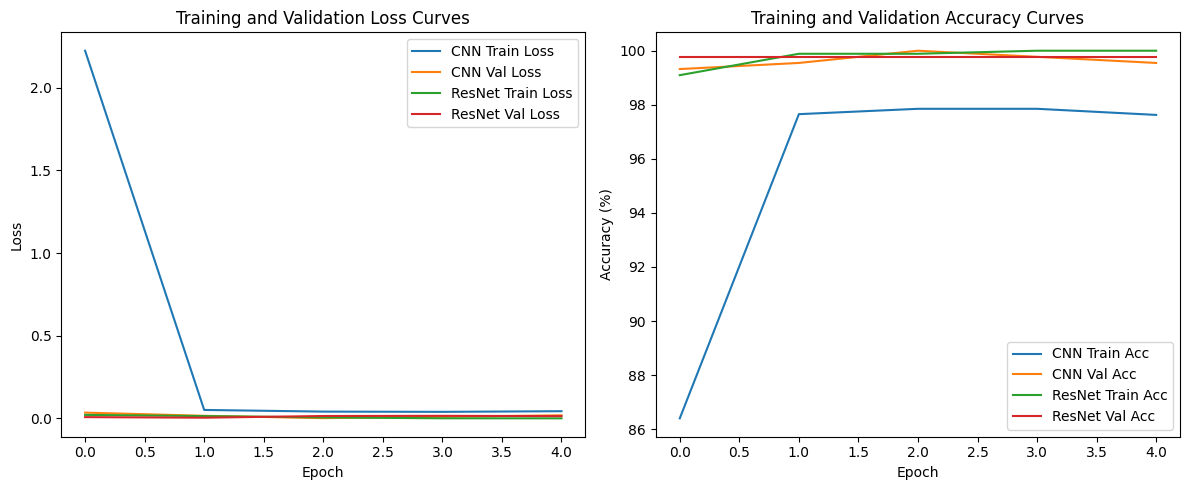

In [3]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Ensure results folder exists
os.makedirs('/content/results', exist_ok=True)

# ==========================================
# 1. DATASET DEFINITION (1-Channel for CNN, 3-Channel for ResNet)
# ==========================================
class TeacherKhmerDataset(Dataset):
    def __init__(self, split, channels=1):
        self.files = []
        self.labels = []
        self.channels = channels
        base_path = f'/content/teacher_dataset_split/{split}'
        for label, folder in enumerate(['real', 'fake']):
            folder_path = os.path.join(base_path, folder)
            if os.path.exists(folder_path):
                for file in os.listdir(folder_path):
                    if file.lower().endswith(('.wav', '.mp3', '.flac', '.m4a', '.ogg')):
                        self.files.append(os.path.join(folder_path, file))
                        self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        label = self.labels[idx]
        audio, sr = librosa.load(file_path, sr=16000, mono=True)
        max_len = 16000 * 3
        if len(audio) < max_len:
            audio = np.pad(audio, (0, max_len - len(audio)))
        else:
            audio = audio[:max_len]

        mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        tensor_spec = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0)

        if self.channels == 3:
            tensor_spec = tensor_spec.repeat(3, 1, 1)

        return tensor_spec, torch.tensor(label, dtype=torch.long)

# Setup DataLoaders (Using a smaller batch size for faster re-training)
train_dataset_1ch = TeacherKhmerDataset('train', channels=1)
val_dataset_1ch = TeacherKhmerDataset('val', channels=1)
train_loader_1ch = DataLoader(train_dataset_1ch, batch_size=32, shuffle=True)
val_loader_1ch = DataLoader(val_dataset_1ch, batch_size=32, shuffle=False)

train_dataset_3ch = TeacherKhmerDataset('train', channels=3)
val_dataset_3ch = TeacherKhmerDataset('val', channels=3)
train_loader_3ch = DataLoader(train_dataset_3ch, batch_size=16, shuffle=True)
val_loader_3ch = DataLoader(val_dataset_3ch, batch_size=16, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using hardware: {device}")

# ==========================================
# 2. TRAINING FUNCTION WITH HISTORY TRACKING
# ==========================================
def train_model(model, train_loader, val_loader, epochs, model_name):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001 if model_name == 'CustomCNN' else 0.0001)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"Training {model_name}...")
    start_time = time.time()

    for epoch in range(epochs):
        # Train
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for specs, labels in train_loader:
            specs, labels = specs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(specs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # Validate
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for specs, labels in val_loader:
                specs, labels = specs.to(device), labels.to(device)
                outputs = model(specs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.1f}%")

    training_time = time.time() - start_time
    print(f"{model_name} training finished in {training_time:.2f} seconds.\n")

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return history, training_time, total_params

# ==========================================
# 3. DEFINE MODELS
# ==========================================
# Approach 1: Custom CNN
class KhmerDeepfakeCNN(nn.Module):
    def __init__(self):
        super(KhmerDeepfakeCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(64),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

# Approach 2: ResNet18
resnet18 = models.resnet18(weights=None)
num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, 2)

# ==========================================
# 4. RUN TRAINING AND PLOT CURVES
# ==========================================
# We use fewer epochs just to generate the curves quickly for the report
cnn_history, cnn_time, cnn_params = train_model(KhmerDeepfakeCNN(), train_loader_1ch, val_loader_1ch, epochs=5, model_name='CustomCNN')
resnet_history, resnet_time, resnet_params = train_model(resnet18, train_loader_3ch, val_loader_3ch, epochs=5, model_name='ResNet18')

# Plot Loss Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history['train_loss'], label='CNN Train Loss')
plt.plot(cnn_history['val_loss'], label='CNN Val Loss')
plt.plot(resnet_history['train_loss'], label='ResNet Train Loss')
plt.plot(resnet_history['val_loss'], label='ResNet Val Loss')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(cnn_history['train_acc'], label='CNN Train Acc')
plt.plot(cnn_history['val_acc'], label='CNN Val Acc')
plt.plot(resnet_history['train_acc'], label='ResNet Train Acc')
plt.plot(resnet_history['val_acc'], label='ResNet Val Acc')
plt.title('Training and Validation Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.savefig('/content/results/training_curves.png', dpi=300)
print("Saved training_curves.png to /content/results/")

# Print Model Statistics for the Report
print("="*50)
print("MODEL STATISTICS FOR REPORT")
print("="*50)
print(f"Hardware Used: {device}")
print(f"Approach 1 (Custom CNN):")
print(f"  - Trainable Parameters: {cnn_params:,}")
print(f"  - Training Time (5 epochs): {cnn_time:.2f} seconds")
print(f"  - Learning Rate: 0.001 | Dropout: 0.5")
print(f"Approach 2 (ResNet18):")
print(f"  - Trainable Parameters: {resnet_params:,}")
print(f"  - Training Time (5 epochs): {resnet_time:.2f} seconds")
print(f"  - Learning Rate: 0.0001 (Transfer Learning)")
print("="*50)

In [4]:
requirements_content = """torch>=2.0.0
torchvision>=0.15.0
librosa>=0.10.0
numpy>=1.24.0
scikit-learn>=1.3.0
matplotlib>=3.7.0
seaborn>=0.12.0
"""

with open('/content/requirements.txt', 'w') as f:
    f.write(requirements_content)

print("requirements.txt created successfully.")

from google.colab import files
files.download('/content/requirements.txt')

requirements.txt created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import shutil
from google.colab import files

# Check if the files exist
import os
files_to_check = [
    '/content/results/resnet18_confusion_matrix.png',
    '/content/results/resnet18_classification_report.txt',
    '/content/results/training_curves.png'
]

print("Checking results folder...")
for f in files_to_check:
    if os.path.exists(f):
        print(f"FOUND: {os.path.basename(f)}")
    else:
        print(f"MISSING: {os.path.basename(f)}")

# Zip and download the entire results folder
shutil.make_archive('/content/results', 'zip', '/content/results')
print("\nZipping results folder...")
files.download('/content/results.zip')

Checking results folder...
MISSING: resnet18_confusion_matrix.png
MISSING: resnet18_classification_report.txt
FOUND: training_curves.png

Zipping results folder...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>